# Day 6 — Multi-Layer Map: B38 Stops

**Theme:** A single-layer map shows one thing. Layering two datasets on the same map lets you ask: *are these patterns related?*

**By the end of this notebook you will have:**
- Converted a CSV of lat/lon coordinates into a GeoDataFrame of points
- Plotted your Day 5 choropleth as the base layer
- Plotted B38 stop locations as a second layer on top
- Visually answered: do high-complaint zip codes have B38 access?

**Key new idea — coordinate reference systems (CRS):**  
Every map layer has to agree on *how the Earth is flattened onto a 2D surface*. That's a CRS.
The most common one is EPSG:4326 — plain latitude/longitude. If two layers have different CRSes, they'll plot in the wrong place relative to each other. You'll check this before plotting.

**No hints unless you ask.**

In [20]:
# Imports: pandas, geopandas, matplotlib.pyplot

import pandas as pd, geopandas as gpd, matplotlib.pyplot as plt


In [27]:
# Rebuild gdf_merged from Day 5.
# You need:
#   - 311_cleaned.csv → complaint_count by zip
#   - pluto.csv (nrows=50000) → lot_count by zip
#   - merge those two into merged
#   - load nyc_zipcodes.geojson into gdf
#   - merge gdf + merged into gdf_merged
#
# You've done all of this. Try it from memory.

df2 = pd.read_csv('../data/311_cleaned.csv')
df1 = pd.read_csv('../data/pluto.csv')
gdf = gpd.read_file('../data/nyczipcodes.geojson')
gdf['modzcta'] = pd.to_numeric(gdf['modzcta'], errors='coerce').astype(float)


complaint_count = df2.groupby('Incident Zip').size().reset_index(name='complaint_count')
zip_counts2 = df1.groupby('postcode').size().reset_index(name='lot_count')

merged = pd.merge(complaint_count, zip_counts2, left_on='Incident Zip', right_on='postcode')


gdf_merged = pd.merge(gdf, merged, left_on='modzcta', right_on='Incident Zip')

print(gdf_merged)




/var/folders/01/7mmm8p_55mz_znpc8yd21gjc0000gn/T/ipykernel_47167/3370556670.py:12: DtypeWarning: Columns (0: zonedist3, 1: zonedist4, 2: overlay2, 3: spdist1, 4: spdist2, 5: ltdheight, 6: splitzone, 7: unitsres, 8: unitstotal, 9: lotfront, 10: lotdepth, 11: bldgfront, 12: bldgdepth, 13: irrlotcode, 14: histdist, 15: landmark, 16: condono, 17: edesignum, 18: dcpedited, 19: mihopt1, 20: mihopt2, 21: mihopt3, 22: mihopt4) have mixed types. Specify dtype option on import or set low_memory=False.
  df1 = pd.read_csv('../data/pluto.csv')


                   :id           :version                      :created_at  \
0   row-huf4~2hg5_z872  rv-v6tk~xk99.f44y 2020-05-13 23:28:10.857000+00:00   
1   row-gmjh_pzhm-3782  rv-wpxa-tjn6.rnda 2020-05-13 23:28:10.857000+00:00   
2   row-9ube-k8t6_bvhe  rv-2acz.jwec.xuuq 2020-05-13 23:28:10.857000+00:00   
3   row-tq4a_2vir_kzfz  rv-b92e.97mw-u75e 2020-05-13 23:28:10.857000+00:00   
4   row-4ewt~9r74-vk99  rv-4nsg-rfse-s6t4 2020-05-13 23:28:10.857000+00:00   
5   row-qj7r_7i8n-xvnr  rv-kxzd_tcen-ihh7 2020-05-13 23:28:10.857000+00:00   
6   row-aqfq-man2_py7e  rv-nwzz~3vru.jvwa 2020-05-13 23:28:10.857000+00:00   
7   row-p6hu_25f9~8myt  rv-tjqq.76rh-eee6 2020-05-13 23:28:10.857000+00:00   
8   row-suwm_954v.pnd2  rv-z8z8-n3mc-5f8i 2020-05-13 23:28:10.857000+00:00   
9   row-4dsg_smqi-75gu  rv-2vxw~x4wg~v2da 2020-05-13 23:28:10.857000+00:00   
10  row-wzcb_fmrp_pcm9  rv-wbz8.ayxz~nkdx 2020-05-13 23:28:10.857000+00:00   
11  row-ripv.9ii5_ypfe  rv-gnw7-2edj_gic3 2020-05-13 23:28:10.85

In [32]:
# Confirm gdf_merged is ready.
# Print its CRS: gdf_merged.crs

print(gdf_merged.crs)


EPSG:4326


## Step 1 — Load the B38 stops from real GTFS data

The MTA `stops.txt` file is a CSV (despite the name) with every bus and subway stop in the system.
GTFS uses `stop_lat` and `stop_lon` as the column names — different from our sample file.

You need to:
1. Load `../data/stops.txt` into a DataFrame called `df_stops`
2. Filter it to DeKalb Ave stops — the B38 runs along DeKalb Ave, so filter where `stop_name` contains `'DEKALB AV'`
3. Convert to a GeoDataFrame using `stop_lon` and `stop_lat`

Note: this gives you all stops on DeKalb Ave, a close approximation of the B38 route.
A more precise filter would join through `routes.txt` → `trips.txt` → `stop_times.txt` — that's a Day 10+ exercise.

The `gpd.GeoDataFrame` pattern stays the same — just swap the column names:
```python
gdf_stops = gpd.GeoDataFrame(
    df_stops,
    geometry=gpd.points_from_xy(df_stops['stop_lon'], df_stops['stop_lat']),
    crs='EPSG:4326'
)
```

In [48]:
# Load ../data/stops.txt into df_stops.
# Filter to rows where stop_name contains 'DE KALB AV'.
# Convert to gdf_stops using stop_lon and stop_lat.
# Print len(gdf_stops) and gdf_stops.head() to verify.

df_stops = pd.read_csv('../data/stops.txt')


filtered_df = df_stops[df_stops['stop_name'].str.contains('DE KALB AV/', case=False, na=False)]

gdf_stops = gpd.GeoDataFrame(filtered_df, geometry=gpd.points_from_xy(filtered_df['stop_lon'], filtered_df['stop_lat']), crs='EPSG:4326')
print(gdf_stops)


      stop_id                      stop_name  stop_desc   stop_lat   stop_lon  \
1123   301931          DE KALB AV/CARLTON AV        NaN  40.689633 -73.972000   
1124   301933   DE KALB AV/SOUTH PORTLAND AV        NaN  40.689752 -73.974946   
1125   301934      DE KALB AV/FORT GREENE PL        NaN  40.689826 -73.976966   
1538   303038        DE KALB AV/EVERGREEN AV        NaN  40.696344 -73.926966   
1539   303039           DE KALB AV/MYRTLE AV        NaN  40.698404 -73.924944   
1540   303040           DE KALB AV/WILSON AV        NaN  40.699506 -73.923869   
1541   303041    DE KALB AV/KNICKERBOCKER AV        NaN  40.701317 -73.922088   
1542   303042           DE KALB AV/IRVING AV        NaN  40.702905 -73.920529   
1543   303043          DE KALB AV/WYCKOFF AV        NaN  40.704487 -73.918961   
1544   303044   DE KALB AV/SAINT NICHOLAS AV        NaN  40.705669 -73.917755   
1545   303072   DE KALB AV/SAINT NICHOLAS AV        NaN  40.705190 -73.918371   
1546   303073          DE KA

## Step 2 — Check that both layers use the same CRS

Print `gdf_merged.crs` and `gdf_stops.crs` side by side.
Both should say `EPSG:4326`. If they don't match, use `.to_crs('EPSG:4326')` to convert.

In [51]:
# Check CRS of both GeoDataFrames.print

print(gdf_merged.crs)
print(gdf_stops.crs)

EPSG:4326
EPSG:4326


## Step 3 — Plot both layers

The trick for layering in geopandas: save the first plot's **axes** into a variable called `ax`,
then pass that same `ax` to the second plot. Both drawings go onto the same canvas.

```python
ax = gdf_merged.plot(...)          # layer 1 — creates the canvas
gdf_stops.plot(ax=ax, ...)         # layer 2 — draws on the same canvas
```

For the stops layer, use `color='blue'`, `markersize=50`, `zorder=2` (puts it on top).

/var/folders/01/7mmm8p_55mz_znpc8yd21gjc0000gn/T/ipykernel_47167/3132723576.py:6: UserWarning: Only specify one of 'column' or 'color'. Using 'color'.
  gdf_stops.plot(ax=ax,column='stop_name', color='blue', markersize=50, zorder=2 )


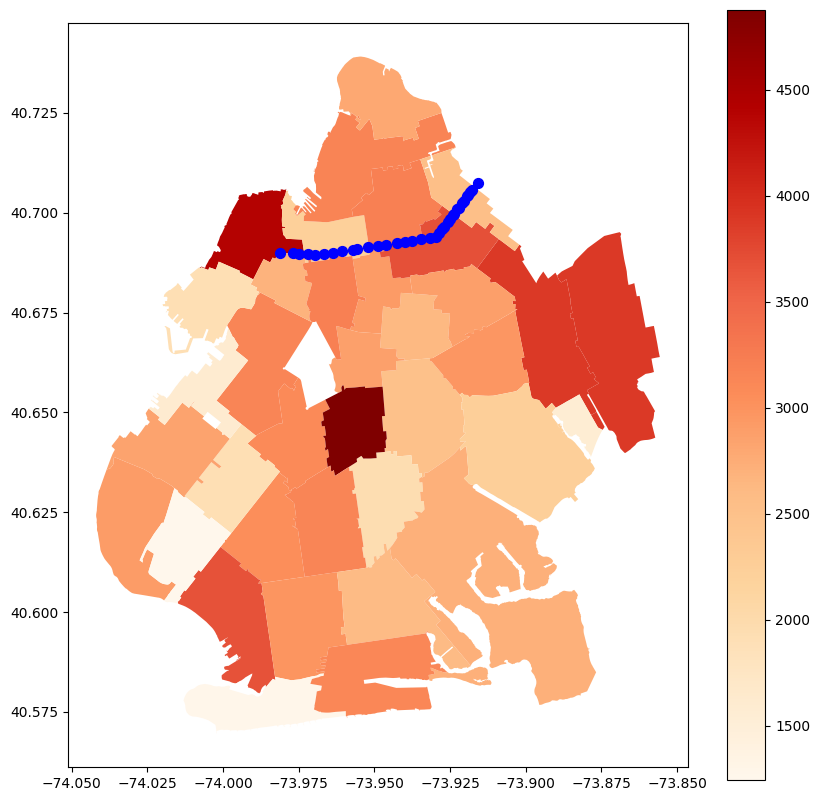

In [54]:
# Plot the choropleth as layer 1 (save axes to ax).
# Plot B38 stops as layer 2 (pass ax=ax).
# Add a title and plt.show().

ax = gdf_merged.plot(column='complaint_count', cmap='OrRd', legend=True, figsize=(10,10))
gdf_stops.plot(ax=ax,column='stop_name', color='blue', markersize=50, zorder=2 )
plt.show()

## Step 4 — Read the map

Look at where the B38 stops fall relative to the shading.

- Do the stops run through high-complaint or low-complaint zip codes?
- Is there a part of the map with high complaints but no nearby stops?
- What zip codes does the B38 *not* serve at all?

Write your observations in a markdown cell below.

*(Your observations here — what do you see?)*

I notice it depends and the B38 actually where the stops are spaced out a bit more does have slightly less complaints. In the spots where the complaints are higher there are more complaints until you start heading towards queens. and as the bus makes it way through clinton hill there are less complaints but once it gets to bedstuy and and parts of bushwick the complaints do start to increase. 

The B38 doesn't serve a lot of zips in brooklyn it's mostly north and downtown brooklyn


## Day 6 Recap

| What you did | Why it matters |
|---|---|
| `gpd.points_from_xy()` | Converts lat/lon columns into spatial geometry |
| `crs=` / `.to_crs()` | Ensures layers are on the same projection |
| `ax=` pattern | The standard way to layer any two geopandas plots |
| Reading the map | Spatial analysis is ultimately about what your eyes find |

### What's coming on Day 7

We bring in **Census ACS data** — income and housing cost burden by block group.
You'll calculate a complaint rate per 1,000 residents and see whether the 11226/11201 hotspots
you noticed on Day 5 are really about conditions or just population density.